
Probabilistic Linear Regression (Gaussian noise model)
-------------------------------------------------------
Slide idea (I2DL, Prof. Niessner):

    p(y_i | x_i, theta)  where  y_i = N(x_i * theta, sigma^2)
                                
                                = x_i * theta + N(0, sigma^2)

    Gaussian:  p(y_i) = 1/sqrt(2*pi*sigma^2) * exp(-(y_i - mu)^2 / (2*sigma^2))

Meaning: instead of treating linear regression as "just fit a line",
we treat each y_i as a RANDOM VARIABLE drawn from a Gaussian whose MEAN
is the line's prediction (x_i * theta) and whose SPREAD is sigma^2 (noise).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Dataset (study_hours -> gpa)
# ---------------------------------------------------------
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])
y = np.array([1.4, 1.6, 2.5, 2.6, 3.5, 3.7, 4.0])
n = len(x)

In [3]:
# ---------------------------------------------------------
# 2. Fit theta (slope, intercept) using least squares
#    X @ theta = y_hat,  X = [x, 1]
# ---------------------------------------------------------
X = np.column_stack([x, np.ones(n)])          # add bias column
theta, *_ = np.linalg.lstsq(X, y, rcond=None) # closed-form least squares
slope, intercept = theta
y_hat = X @ theta                             # mean predictions: x_i * theta

print(f"Fitted line: gpa = {slope:.4f} * study_hours + {intercept:.4f}")

Fitted line: gpa = 0.4643 * study_hours + 0.9000


In [4]:
# ---------------------------------------------------------
# 3. Estimate sigma^2 (noise variance) via MLE
#    sigma^2 = (1/n) * sum((y_i - y_hat_i)^2)
# ---------------------------------------------------------
residuals = y - y_hat
sigma2 = np.mean(residuals ** 2)
sigma = np.sqrt(sigma2)
print(f"Estimated sigma^2 (noise variance) = {sigma2:.5f}")
print(f"Estimated sigma (std dev)          = {sigma:.5f}")

Estimated sigma^2 (noise variance) = 0.03163
Estimated sigma (std dev)          = 0.17786


In [5]:
# ---------------------------------------------------------
# 4. Gaussian PDF:  p(y_i) = 1/sqrt(2*pi*sigma^2) * exp(-(y_i-mu)^2/(2*sigma^2))
# ---------------------------------------------------------
def gaussian_pdf(y_val, mu, sigma2):
    return (1.0 / np.sqrt(2 * np.pi * sigma2)) * np.exp(-(y_val - mu) ** 2 / (2 * sigma2))

# probability density of each observed y_i under the model, y_i ~ N(x_i*theta, sigma^2)
densities = gaussian_pdf(y, y_hat, sigma2)
for i in range(n):
    print(f"x={x[i]:.1f}  y={y[i]:.2f}  mu=x*theta={y_hat[i]:.2f}  p(y_i)={densities[i]:.4f}")


x=1.0  y=1.40  mu=x*theta=1.36  p(y_i)=2.1983
x=2.0  y=1.60  mu=x*theta=1.83  p(y_i)=0.9822
x=3.0  y=2.50  mu=x*theta=2.29  p(y_i)=1.1384
x=4.0  y=2.60  mu=x*theta=2.76  p(y_i)=1.5182
x=5.0  y=3.50  mu=x*theta=3.22  p(y_i)=0.6579
x=6.0  y=3.70  mu=x*theta=3.69  p(y_i)=2.2358
x=7.0  y=4.00  mu=x*theta=4.15  p(y_i)=1.5718


In [7]:
# ---------------------------------------------------------
# 5. Likelihood / log-likelihood of the whole dataset
#    L(theta) = product_i p(y_i | x_i, theta)
#    log L(theta) = sum_i log p(y_i | x_i, theta)
# ---------------------------------------------------------
log_likelihood = np.sum(np.log(densities))
likelihood = np.prod(densities)
print(f"\nTotal log-likelihood = {log_likelihood:.4f}")
print(f"Total likelihood     = {likelihood:.6e}")


Total log-likelihood = 2.1549
Total likelihood     = 8.627106e+00


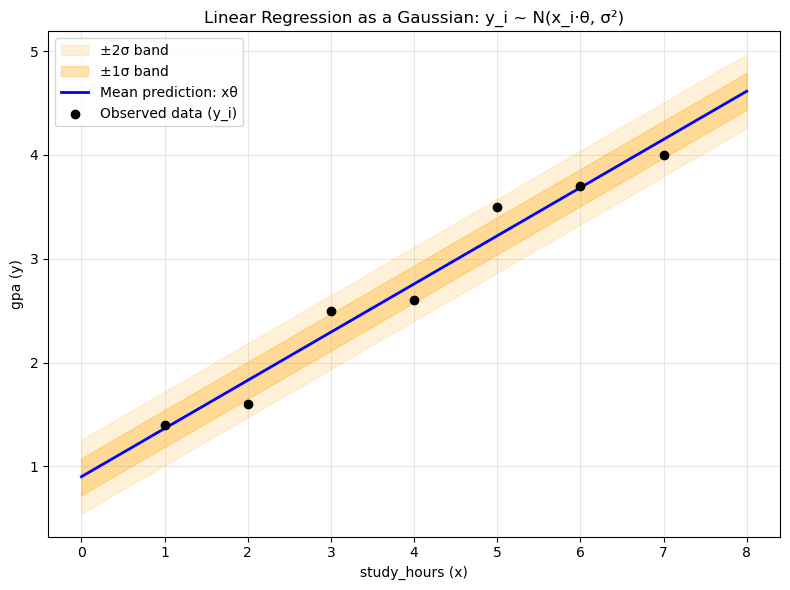

In [8]:
# ---------------------------------------------------------
# 6. Plot: data, regression line (the mean), and Gaussian noise band (+-1 sigma, +-2 sigma)
# ---------------------------------------------------------
x_line = np.linspace(0, 8, 200)
y_line = slope * x_line + intercept

plt.figure(figsize=(8, 6))
plt.fill_between(x_line, y_line - 2*sigma, y_line + 2*sigma, color="orange", alpha=0.15, label="±2σ band")
plt.fill_between(x_line, y_line - sigma,   y_line + sigma,   color="orange", alpha=0.3,  label="±1σ band")
plt.plot(x_line, y_line, color="blue", linewidth=2, label="Mean prediction: xθ")
plt.scatter(x, y, color="black", zorder=5, label="Observed data (y_i)")
plt.title("Linear Regression as a Gaussian: y_i ~ N(x_i·θ, σ²)")
plt.xlabel("study_hours (x)")
plt.ylabel("gpa (y)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig("/mnt/user-data/outputs/gaussian_regression_plot.png", dpi=150)
# print("\nSaved plot -> gaussian_regression_plot.png")

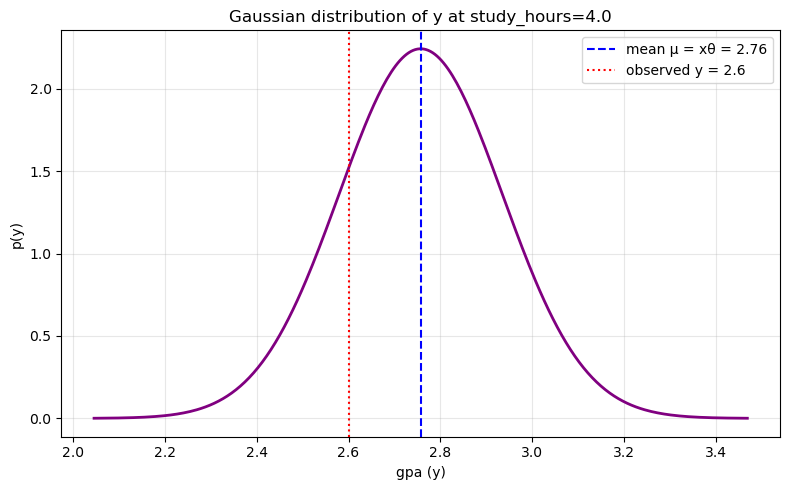

In [9]:
# ---------------------------------------------------------
# 7. Bonus: plot the actual Gaussian bell curve for one specific point
#    e.g. study_hours = 4.0, showing p(y_i) as a full distribution
# ---------------------------------------------------------
idx = 3  # x=4.0
mu_point = y_hat[idx]
y_range = np.linspace(mu_point - 4*sigma, mu_point + 4*sigma, 300)
pdf_vals = gaussian_pdf(y_range, mu_point, sigma2)

plt.figure(figsize=(8, 5))
plt.plot(y_range, pdf_vals, color="purple", linewidth=2)
plt.axvline(mu_point, color="blue", linestyle="--", label=f"mean μ = xθ = {mu_point:.2f}")
plt.axvline(y[idx], color="red", linestyle=":", label=f"observed y = {y[idx]}")
plt.title(f"Gaussian distribution of y at study_hours={x[idx]}")
plt.xlabel("gpa (y)")
plt.ylabel("p(y)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig("/mnt/user-data/outputs/gaussian_single_point.png", dpi=150)
# print("Saved plot -> gaussian_single_point.png")

# **LAPLACE DISTRIBUTION**

Fitted line: gpa = 0.4643 * study_hours + 0.9000
Estimated b (Laplace scale) = 0.15306
x=1.0  y=1.40  mu=x*theta=1.36  p(y_i)=2.5868
x=2.0  y=1.60  mu=x*theta=1.83  p(y_i)=0.7338
x=3.0  y=2.50  mu=x*theta=2.29  p(y_i)=0.8440
x=4.0  y=2.60  mu=x*theta=2.76  p(y_i)=1.1701
x=5.0  y=3.50  mu=x*theta=3.22  p(y_i)=0.5293
x=6.0  y=3.70  mu=x*theta=3.69  p(y_i)=2.9756
x=7.0  y=4.00  mu=x*theta=4.15  p(y_i)=1.2260

Total log-likelihood = 1.2864
Total likelihood     = 3.619698e+00


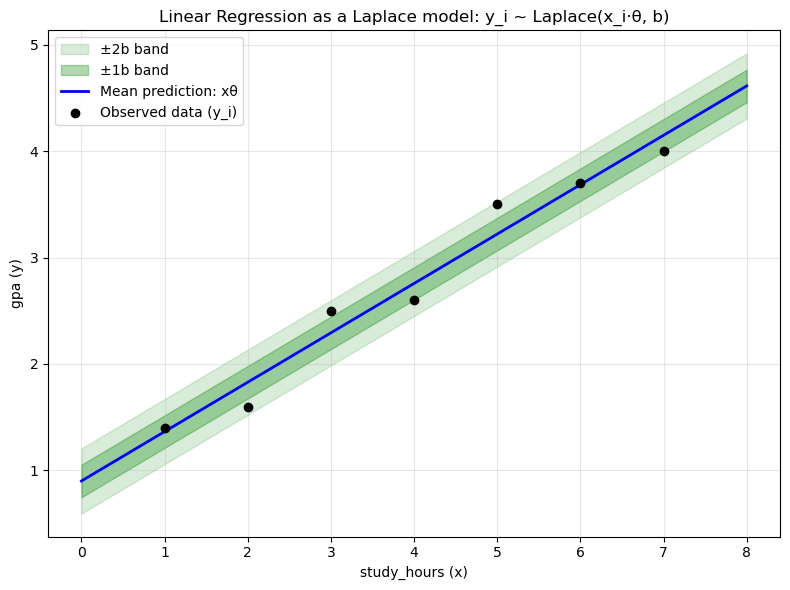

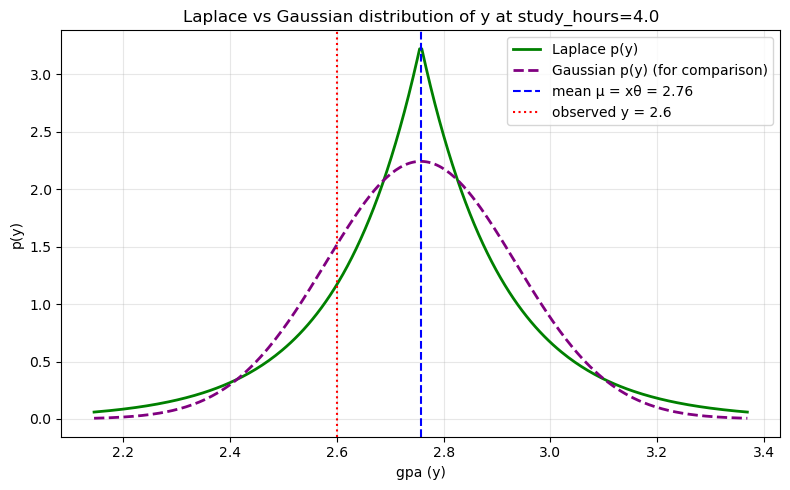

In [11]:
"""
Probabilistic Linear Regression (Laplace noise model)
-------------------------------------------------------
Same idea as the Gaussian version, but now we assume the noise around
the regression line follows a LAPLACE distribution instead of a Gaussian:

    y_i = x_i * theta + Laplace(0, b)

    Laplace PDF:  p(y_i) = 1/(2b) * exp(-|y_i - mu_i| / b)

Where:
    mu_i = x_i * theta   (same line/mean as before)
    b    = scale parameter (like sigma, but for Laplace).
           MLE estimate: b = mean(|residuals|)   <-- uses ABSOLUTE error,
           not squared error like Gaussian's sigma^2.

Key difference vs Gaussian:
    - Gaussian assumes noise clusters tightly around the mean (bell curve),
      heavily penalizing large deviations (squared error).
    - Laplace has "fatter tails" -> more tolerant of occasional big outliers,
      and its peak is sharper (more probability mass exactly at the mean).
    - Minimizing under a Laplace assumption is mathematically equivalent to
      minimizing MEAN ABSOLUTE ERROR (MAE), not MSE.
"""



# ---------------------------------------------------------
# 1. Dataset (same as before)
# ---------------------------------------------------------
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])
y = np.array([1.4, 1.6, 2.5, 2.6, 3.5, 3.7, 4.0])
n = len(x)

# ---------------------------------------------------------
# 2. Fit theta (slope, intercept) - same least squares line
#    (the mean/location function mu_i = x_i * theta stays the same;
#     only the NOISE MODEL around it changes)
# ---------------------------------------------------------
X = np.column_stack([x, np.ones(n)])
theta, *_ = np.linalg.lstsq(X, y, rcond=None)
slope, intercept = theta
y_hat = X @ theta   # mu_i = x_i * theta

print(f"Fitted line: gpa = {slope:.4f} * study_hours + {intercept:.4f}")

# ---------------------------------------------------------
# 3. Estimate b (Laplace scale parameter) via MLE
#    b = (1/n) * sum(|y_i - mu_i|)   <-- MEAN ABSOLUTE residual
# ---------------------------------------------------------
residuals = y - y_hat
b = np.mean(np.abs(residuals))
print(f"Estimated b (Laplace scale) = {b:.5f}")

# ---------------------------------------------------------
# 4. Laplace PDF:  p(y_i) = 1/(2b) * exp(-|y_i - mu_i| / b)
# ---------------------------------------------------------
def laplace_pdf(y_val, mu, b):
    return (1.0 / (2 * b)) * np.exp(-np.abs(y_val - mu) / b)

densities = laplace_pdf(y, y_hat, b)
for i in range(n):
    print(f"x={x[i]:.1f}  y={y[i]:.2f}  mu=x*theta={y_hat[i]:.2f}  p(y_i)={densities[i]:.4f}")

# ---------------------------------------------------------
# 5. Likelihood / log-likelihood of the whole dataset
# ---------------------------------------------------------
log_likelihood = np.sum(np.log(densities))
likelihood = np.prod(densities)
print(f"\nTotal log-likelihood = {log_likelihood:.4f}")
print(f"Total likelihood     = {likelihood:.6e}")

# ---------------------------------------------------------
# 6. Plot: data, regression line, and Laplace noise band
# ---------------------------------------------------------
x_line = np.linspace(0, 8, 200)
y_line = slope * x_line + intercept

plt.figure(figsize=(8, 6))
plt.fill_between(x_line, y_line - 2*b, y_line + 2*b, color="green", alpha=0.15, label="±2b band")
plt.fill_between(x_line, y_line - b,   y_line + b,   color="green", alpha=0.3,  label="±1b band")
plt.plot(x_line, y_line, color="blue", linewidth=2, label="Mean prediction: xθ")
plt.scatter(x, y, color="black", zorder=5, label="Observed data (y_i)")
plt.title("Linear Regression as a Laplace model: y_i ~ Laplace(x_i·θ, b)")
plt.xlabel("study_hours (x)")
plt.ylabel("gpa (y)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/laplace_regression_plot.png", dpi=150)
# print("\nSaved plot -> laplace_regression_plot.png")
plt.show()

# ---------------------------------------------------------
# 7. Bonus: plot the actual Laplace curve for one point (study_hours = 4.0)
#    and compare its shape against a Gaussian with the same data point
# ---------------------------------------------------------
idx = 3  # x = 4.0
mu_point = y_hat[idx]

y_range = np.linspace(mu_point - 4*b, mu_point + 4*b, 300)
laplace_vals = laplace_pdf(y_range, mu_point, b)

# for comparison, overlay a Gaussian using the same data's sigma
sigma2 = np.mean(residuals ** 2)
sigma = np.sqrt(sigma2)
gaussian_vals = (1.0 / np.sqrt(2 * np.pi * sigma2)) * np.exp(-(y_range - mu_point) ** 2 / (2 * sigma2))

plt.figure(figsize=(8, 5))
plt.plot(y_range, laplace_vals, color="green", linewidth=2, label="Laplace p(y)")
plt.plot(y_range, gaussian_vals, color="purple", linewidth=2, linestyle="--", label="Gaussian p(y) (for comparison)")
plt.axvline(mu_point, color="blue", linestyle="--", label=f"mean μ = xθ = {mu_point:.2f}")
plt.axvline(y[idx], color="red", linestyle=":", label=f"observed y = {y[idx]}")
plt.title(f"Laplace vs Gaussian distribution of y at study_hours={x[idx]}")
plt.xlabel("gpa (y)")
plt.ylabel("p(y)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/laplace_vs_gaussian.png", dpi=150)
# print("Saved plot -> laplace_vs_gaussian.png")
plt.show()

In deep learning, **Maximum Likelihood Estimation (MLE)** is the foundational statistical framework used to train neural networks. It frame learning as finding the parameter values $\boldsymbol{\theta}$ (the weights and biases) that maximize the probability—or likelihood—of observing the given training data.

---

### Core Concept & Mathematical Formulation

Given a dataset of $N$ independent and identically distributed (i.i.d.) examples $\mathcal{D} = \{(\mathbf{x}^{(1)}, \mathbf{y}^{(1)}), (\mathbf{x}^{(2)}, \mathbf{y}^{(2)}), \dots, (\mathbf{x}^{(N)}, \mathbf{y}^{(N)})\}$, a neural network acts as a parametric model $p(\mathbf{y} \mid \mathbf{x}; \boldsymbol{\theta})$ that estimates the conditional distribution of target $\mathbf{y}$ given input $\mathbf{x}$.

The likelihood function $L(\boldsymbol{\theta})$ measures how likely the model parameters $\boldsymbol{\theta}$ are to produce the observed training labels:

$$L(\boldsymbol{\theta}) = \prod_{i=1}^{N} p(\mathbf{y}^{(i)} \mid \mathbf{x}^{(i)}; \boldsymbol{\theta})$$

To optimize this numerically, we take the natural logarithm (turning products into sums to prevent arithmetic underflow) and invert the sign to convert the maximization problem into a minimization problem suited for gradient descent:

$$\boldsymbol{\theta}_{\text{MLE}} = \arg\min_{\boldsymbol{\theta}} \mathbb{E}_{(\mathbf{x}, \mathbf{y}) \sim \hat{p}_{\text{data}}} [-\log p(\mathbf{y} \mid \mathbf{x}; \boldsymbol{\theta})]$$

Minimizing the **Negative Log-Likelihood (NLL)** is mathematically equivalent to minimizing the **Kullback-Leibler (KL) divergence** between the true empirical data distribution $\hat{p}_{\text{data}}$ and the model's predicted distribution $p_{\boldsymbol{\theta}}$.

---

### How MLE Generates Standard Loss Functions

The choice of predicted output distribution dictates the specific loss function used during training:

| Task / Problem Type | Assumed Distribution $p(\mathbf{y} \mid \mathbf{x}; \boldsymbol{\theta})$ | Resulting NLL Loss Function |
| --- | --- | --- |
| **Binary Classification** | **Bernoulli Distribution** | Binary Cross-Entropy (BCE) Loss |
| **Multi-Class Classification** | **Categorical Distribution** | Categorical Cross-Entropy Loss (Softmax + NLL) |
| **Regression (Mean Only)** | **Gaussian** ($\mu = f(\mathbf{x};\boldsymbol{\theta})$, constant variance $\sigma^2$) | Mean Squared Error (MSE) Loss |
| **Regression (Absolute Error)** | **Laplace Distribution** | Mean Absolute Error (MAE) Loss |

---

### Key Strengths & Limitations

* **Asymptotic Efficiency:** As the sample size $N \to \infty$, MLE converges to the true data-generating distribution faster than other estimators.
* **Uncertainty Quantification:** Unlike simple point prediction, formulating model outputs as probability distributions lets models output variance or confidence intervals (e.g., heteroscedastic regression).
* **Overfitting Sensitivity:** Plain MLE is prone to overfitting small datasets because it optimizes purely for training data. Regularization techniques (like $L_2$ weight decay) transform MLE into **Maximum A Posteriori (MAP)** estimation by introducing a prior distribution $p(\boldsymbol{\theta})$ over the weights.

# **Regularization**

In [12]:
"""
L1 (Lasso) vs L2 (Ridge) regularization - numeric demo
--------------------------------------------------------
Simulates the "dog classifier" slide: 5 binary features per dog image
(furry, has_two_eyes, has_tail, has_paws, has_two_ears), where in reality
only 2 features actually matter for the label (is_dog), and the other 3
are noisy/redundant.

We fit plain Linear Regression, L1 (Lasso), and L2 (Ridge) on the SAME
data and print the learned weights side by side, so you can see:
  - L1 drives weak/redundant features' weights to EXACTLY 0 (sparsity)
  - L2 shrinks everything a bit but keeps all weights non-zero
"""

import numpy as np
from sklearn.linear_model import LinearRegression, Lasso, Ridge

np.random.seed(42)

# ---------------------------------------------------------
# 1. Simulate data: 200 dog images, 5 features
#    Only "has_two_eyes" and "has_tail" truly drive the label;
#    the rest are noise / redundant signals.
# ---------------------------------------------------------
n_samples = 200
furry        = np.random.rand(n_samples)
has_two_eyes = np.random.rand(n_samples)
has_tail     = np.random.rand(n_samples)
has_paws     = np.random.rand(n_samples)
has_two_ears = np.random.rand(n_samples)

X = np.column_stack([furry, has_two_eyes, has_tail, has_paws, has_two_ears])
feature_names = ["furry", "has_two_eyes", "has_tail", "has_paws", "has_two_ears"]

# true label only depends on has_two_eyes and has_tail (+ small noise)
true_weights = np.array([0.0, 3.0, 2.5, 0.0, 0.0])
noise = np.random.normal(0, 0.3, n_samples)
y = X @ true_weights + noise

# ---------------------------------------------------------
# 2. Fit three models on the same data
# ---------------------------------------------------------
linreg = LinearRegression().fit(X, y)
lasso  = Lasso(alpha=0.1).fit(X, y)     # L1 (weaker alpha so strong features survive)
ridge  = Ridge(alpha=0.1).fit(X, y)     # L2

# ---------------------------------------------------------
# 3. Print weights side by side
# ---------------------------------------------------------
print(f"{'Feature':<15}{'No Reg':>10}{'L1 (Lasso)':>14}{'L2 (Ridge)':>14}")
print("-" * 53)
for i, name in enumerate(feature_names):
    print(f"{name:<15}{linreg.coef_[i]:>10.3f}{lasso.coef_[i]:>14.3f}{ridge.coef_[i]:>14.3f}")

print("\nNumber of exactly-zero weights:")
print(f"  No Reg:     {np.sum(linreg.coef_ == 0)}")
print(f"  L1 (Lasso): {np.sum(lasso.coef_ == 0)}   <- sparsity: irrelevant features eliminated")
print(f"  L2 (Ridge): {np.sum(ridge.coef_ == 0)}   <- all features kept, just shrunk")

Feature            No Reg    L1 (Lasso)    L2 (Ridge)
-----------------------------------------------------
furry              -0.155        -0.000        -0.155
has_two_eyes        3.045         1.719         3.025
has_tail            2.612         1.398         2.595
has_paws           -0.069         0.000        -0.066
has_two_ears       -0.069        -0.000        -0.071

Number of exactly-zero weights:
  No Reg:     0
  L1 (Lasso): 3   <- sparsity: irrelevant features eliminated
  L2 (Ridge): 0   <- all features kept, just shrunk
